<a href="https://colab.research.google.com/github/UNSW-ZZSC9020/project/blob/main/src/GoogleColab.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Liz Multiple Linear Regression

Load data:

In [173]:
# Import Required Packages
import math
import glob
import os
import zipfile
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import holidays
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn import preprocessing
import statsmodels.api as sm
import scipy.stats as stats
from scipy.optimize import curve_fit

In [174]:
# For use in Visual Studio

#Get all part files in order
part_files = sorted(glob.glob("data/NSW/forecastdemand_nsw.csv.zip.part*"))

# Combine them into one ZIP file
with open("data/NSW/forecastdemand_nsw.csv.zip", "wb") as output:
    for part in part_files:
        with open(part, "rb") as pf:
            output.write(pf.read())
print("Zip file reconstructed successfully")

Zip file reconstructed successfully


In [175]:
# Unzip the data files into the data folder

# List of zip files and destination folder
zip_files = [
    "data/NSW/forecastdemand_nsw.csv.zip",
    "data/NSW/temperature_nsw.csv.zip",
    "data/NSW/totaldemand_nsw.csv.zip"
]
destination_folder = "data"

# Unzip each file
for zip_path in zip_files:
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(destination_folder)
        print(f"Extracted: {zip_path} → {destination_folder}")
    except FileNotFoundError:
        print(f"File not found: {zip_path}")
    except zipfile.BadZipFile:
        print(f"Invalid ZIP file: {zip_path}")
    except Exception as e:
        print(f"Error extracting {zip_path}: {e}")


Extracted: data/NSW/forecastdemand_nsw.csv.zip → data
Extracted: data/NSW/temperature_nsw.csv.zip → data
Extracted: data/NSW/totaldemand_nsw.csv.zip → data


In [176]:
# Remove the ZIP file if it exists
zip_path = "data/NSW/forecastdemand_nsw.csv.zip"
try:
    os.remove(zip_path)
    print(f"Removed: {zip_path}")
except FileNotFoundError:
    print(f"File not found (skipped): {zip_path}")
except Exception as e:
    print(f"Error removing {zip_path}: {e}")

# List contents of the 'data' folder with file sizes
data_folder = "data"
try:
    print("\nContents of 'data' folder:")
    for filename in os.listdir(data_folder):
        filepath = os.path.join(data_folder, filename)
        if os.path.isfile(filepath):
            size_kb = os.path.getsize(filepath) / 1024
            print(f"{filename:<40} {size_kb:>10.2f} KB")
except Exception as e:
    print(f"Error listing files in {data_folder}: {e}")


Removed: data/NSW/forecastdemand_nsw.csv.zip

Contents of 'data' folder:
forecastdemand_nsw.csv                    722297.76 KB
temperature_nsw.csv                         6716.26 KB
totaldemand_nsw.csv                         5660.43 KB


In [177]:
# Create dataframes

df_forecast = pd.read_csv('data/forecastdemand_nsw.csv')
df_temperature = pd.read_csv('data/temperature_nsw.csv')
df_totaldemand = pd.read_csv('data/totaldemand_nsw.csv')

In [178]:
# Remove unzipped files to save space

# List of files to remove
files_to_remove = [
    "data/forecastdemand_nsw.csv",
    "data/temperature_nsw.csv",
    "data/totaldemand_nsw.csv"
]

# Remove each file if it exists
for file_path in files_to_remove:
    try:
        os.remove(file_path)
        print(f"Removed: {file_path}")
    except FileNotFoundError:
        print(f"File not found (skipped): {file_path}")
    except Exception as e:
        print(f"Error removing {file_path}: {e}")


Removed: data/forecastdemand_nsw.csv
Removed: data/temperature_nsw.csv
Removed: data/totaldemand_nsw.csv


Add additional data:

In [179]:
# Get NSW public holidays
nsw_holidays = holidays.country_holidays('AU', subdiv='NSW')

Convert 30 minute data points into Daily data points:

In [180]:
# Convert all to pandas datetime and normalize to day-level

# Convert DATETIME column to pandas datetime
def convert_datetime(df):
    df['DATETIME'] = pd.to_datetime(df['DATETIME'], format='mixed', dayfirst=True, errors='coerce')
    return df

# Apply conversion to all datasets
df_forecast = convert_datetime(df_forecast)
df_temperature = convert_datetime(df_temperature)
df_totaldemand = convert_datetime(df_totaldemand)


# Group forecast by DATETIME and average
df_forecast_avg = df_forecast.groupby('DATETIME', as_index=False)['FORECASTDEMAND'].mean()

# Merge all DataFrames on 'DATETIME'
df_merged = df_forecast_avg.merge(df_totaldemand[['DATETIME', 'TOTALDEMAND']], on='DATETIME', how='left') \
                           .merge(df_temperature[['DATETIME', 'TEMPERATURE']], on='DATETIME', how='left')

# Resample by day and calculate min, max, and mean for TEMPERATURE

# Set 'DATETIME' as index before resampling
df_merged = df_merged.set_index('DATETIME')

df_daily = df_merged.resample('D').agg({
    'TEMPERATURE': ['min', 'max', 'mean'],
    'FORECASTDEMAND': ['min', 'max', 'mean'],
    'TOTALDEMAND': ['min', 'max', 'mean']
})

# Create binary features for extreme temperature events
df_daily['extreme_hot'] = (df_daily['TEMPERATURE']['max'] > 35).astype(bool)
df_daily['extreme_cold'] = (df_daily['TEMPERATURE']['min'] < 5).astype(bool)


print(df_daily.head())
print(df_daily.shape)




           TEMPERATURE                  FORECASTDEMAND                \
                   min   max       mean            min           max   
DATETIME                                                               
2010-01-01        22.1  28.8  25.185417    6005.058788   9064.004035   
2010-01-02        22.2  29.4  24.795833    5889.610380   9103.866604   
2010-01-03        17.9  21.5  19.462500    5887.778481   8390.429130   
2010-01-04        17.9  23.9  20.847917    6180.682436  10032.460400   
2010-01-05        15.4  27.7  22.660417    6300.561026  10685.659636   

                        TOTALDEMAND                        extreme_hot  \
                   mean         min       max         mean               
DATETIME                                                                 
2010-01-01  7723.688982     6198.61   8883.98  7801.352917       False   
2010-01-02  7804.668591     6140.82   9294.07  8017.459792       False   
2010-01-03  7491.520488     6059.53   8247.61  7399.8

Create Model Features:

In [181]:
# Create feature matrix X with multiple columns
X = pd.DataFrame({
    'datetime': df_daily.index,
    'temp_mean': df_daily['TEMPERATURE']['mean'],
    'temp_min': df_daily['TEMPERATURE']['min'],
    'temp_max': df_daily['TEMPERATURE']['max'],
    'extreme_hot': df_daily['extreme_hot'],
    'extreme_cold': df_daily['extreme_cold']
})
# Target variable
y= df_daily['TOTALDEMAND']['max'].values


# Rolling averages (3-day mean temperature)
X['temp_rolling3'] = X['temp_mean'].rolling(window=3, min_periods=1).mean()
X['temp_diff'] = X['temp_mean'] - X['temp_mean'].shift(1)
# Add day of week and month - feature engineering
X['dayofweek'] = X['datetime'].dt.dayofweek
X['month'] = X['datetime'].dt.month
X['is_holiday'] = X['datetime'].dt.date.apply(lambda x: bool(x in nsw_holidays))

# Create lagged forecast demand feature
df_daily['forecast_24H'] = df_daily['FORECASTDEMAND']['mean'].shift(1)



# Add to feature matrix X
X['forecast_24H'] = df_daily['forecast_24H'].values




# One-hot encode day of week, month
X = pd.get_dummies(X, columns=['dayofweek', 'month'], drop_first=False)

# Feature matrix X and target y
feature_cols = ['temp_mean', 'temp_min', 'temp_max', 'temp_rolling3', 'temp_diff', 'forecast_24H', 'extreme_hot', 'extreme_cold', 'is_holiday'] + \
               [col for col in X.columns if col.startswith('dayofweek_') or col.startswith('month_')]
X = X[feature_cols].fillna(0)

# Rename day and month columns for better clarity
# Mapping dictionaries
day_map = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
    4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}

month_map = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

# Rename columns
X.rename(columns={
    **{f'dayofweek_{i}': day_map[i] for i in day_map},
    **{f'month_{i}': month_map[i] for i in month_map}
}, inplace=True)

# Remove first row to account for previous 24H forecast demand 
X = X.iloc[1:].reset_index(drop=True)
y = y[1:]
df_daily = df_daily.iloc[1:].reset_index(drop=True)

print(X.head())
print(X.dtypes)

print(y[:5])

print(X['forecast_24H'].describe())
print(X['forecast_24H'].value_counts())


   temp_mean  temp_min  temp_max  temp_rolling3  temp_diff  forecast_24H  \
0  24.795833      22.2      29.4      24.990625  -0.389583   7723.688982   
1  19.462500      17.9      21.5      23.147917  -5.333333   7804.668591   
2  20.847917      17.9      23.9      21.702083   1.385417   7491.520488   
3  22.660417      15.4      27.7      20.990278   1.812500   8592.014274   
4  22.695833      20.3      25.6      22.068056   0.035417   8907.999454   

   extreme_hot  extreme_cold  is_holiday  Monday  ...  March  April    May  \
0        False         False       False   False  ...  False  False  False   
1        False         False       False   False  ...  False  False  False   
2        False         False       False    True  ...  False  False  False   
3        False         False       False   False  ...  False  False  False   
4        False         False       False   False  ...  False  False  False   

    June   July  August  September  October  November  December  
0  False

Conduct some exploratory data analysis:

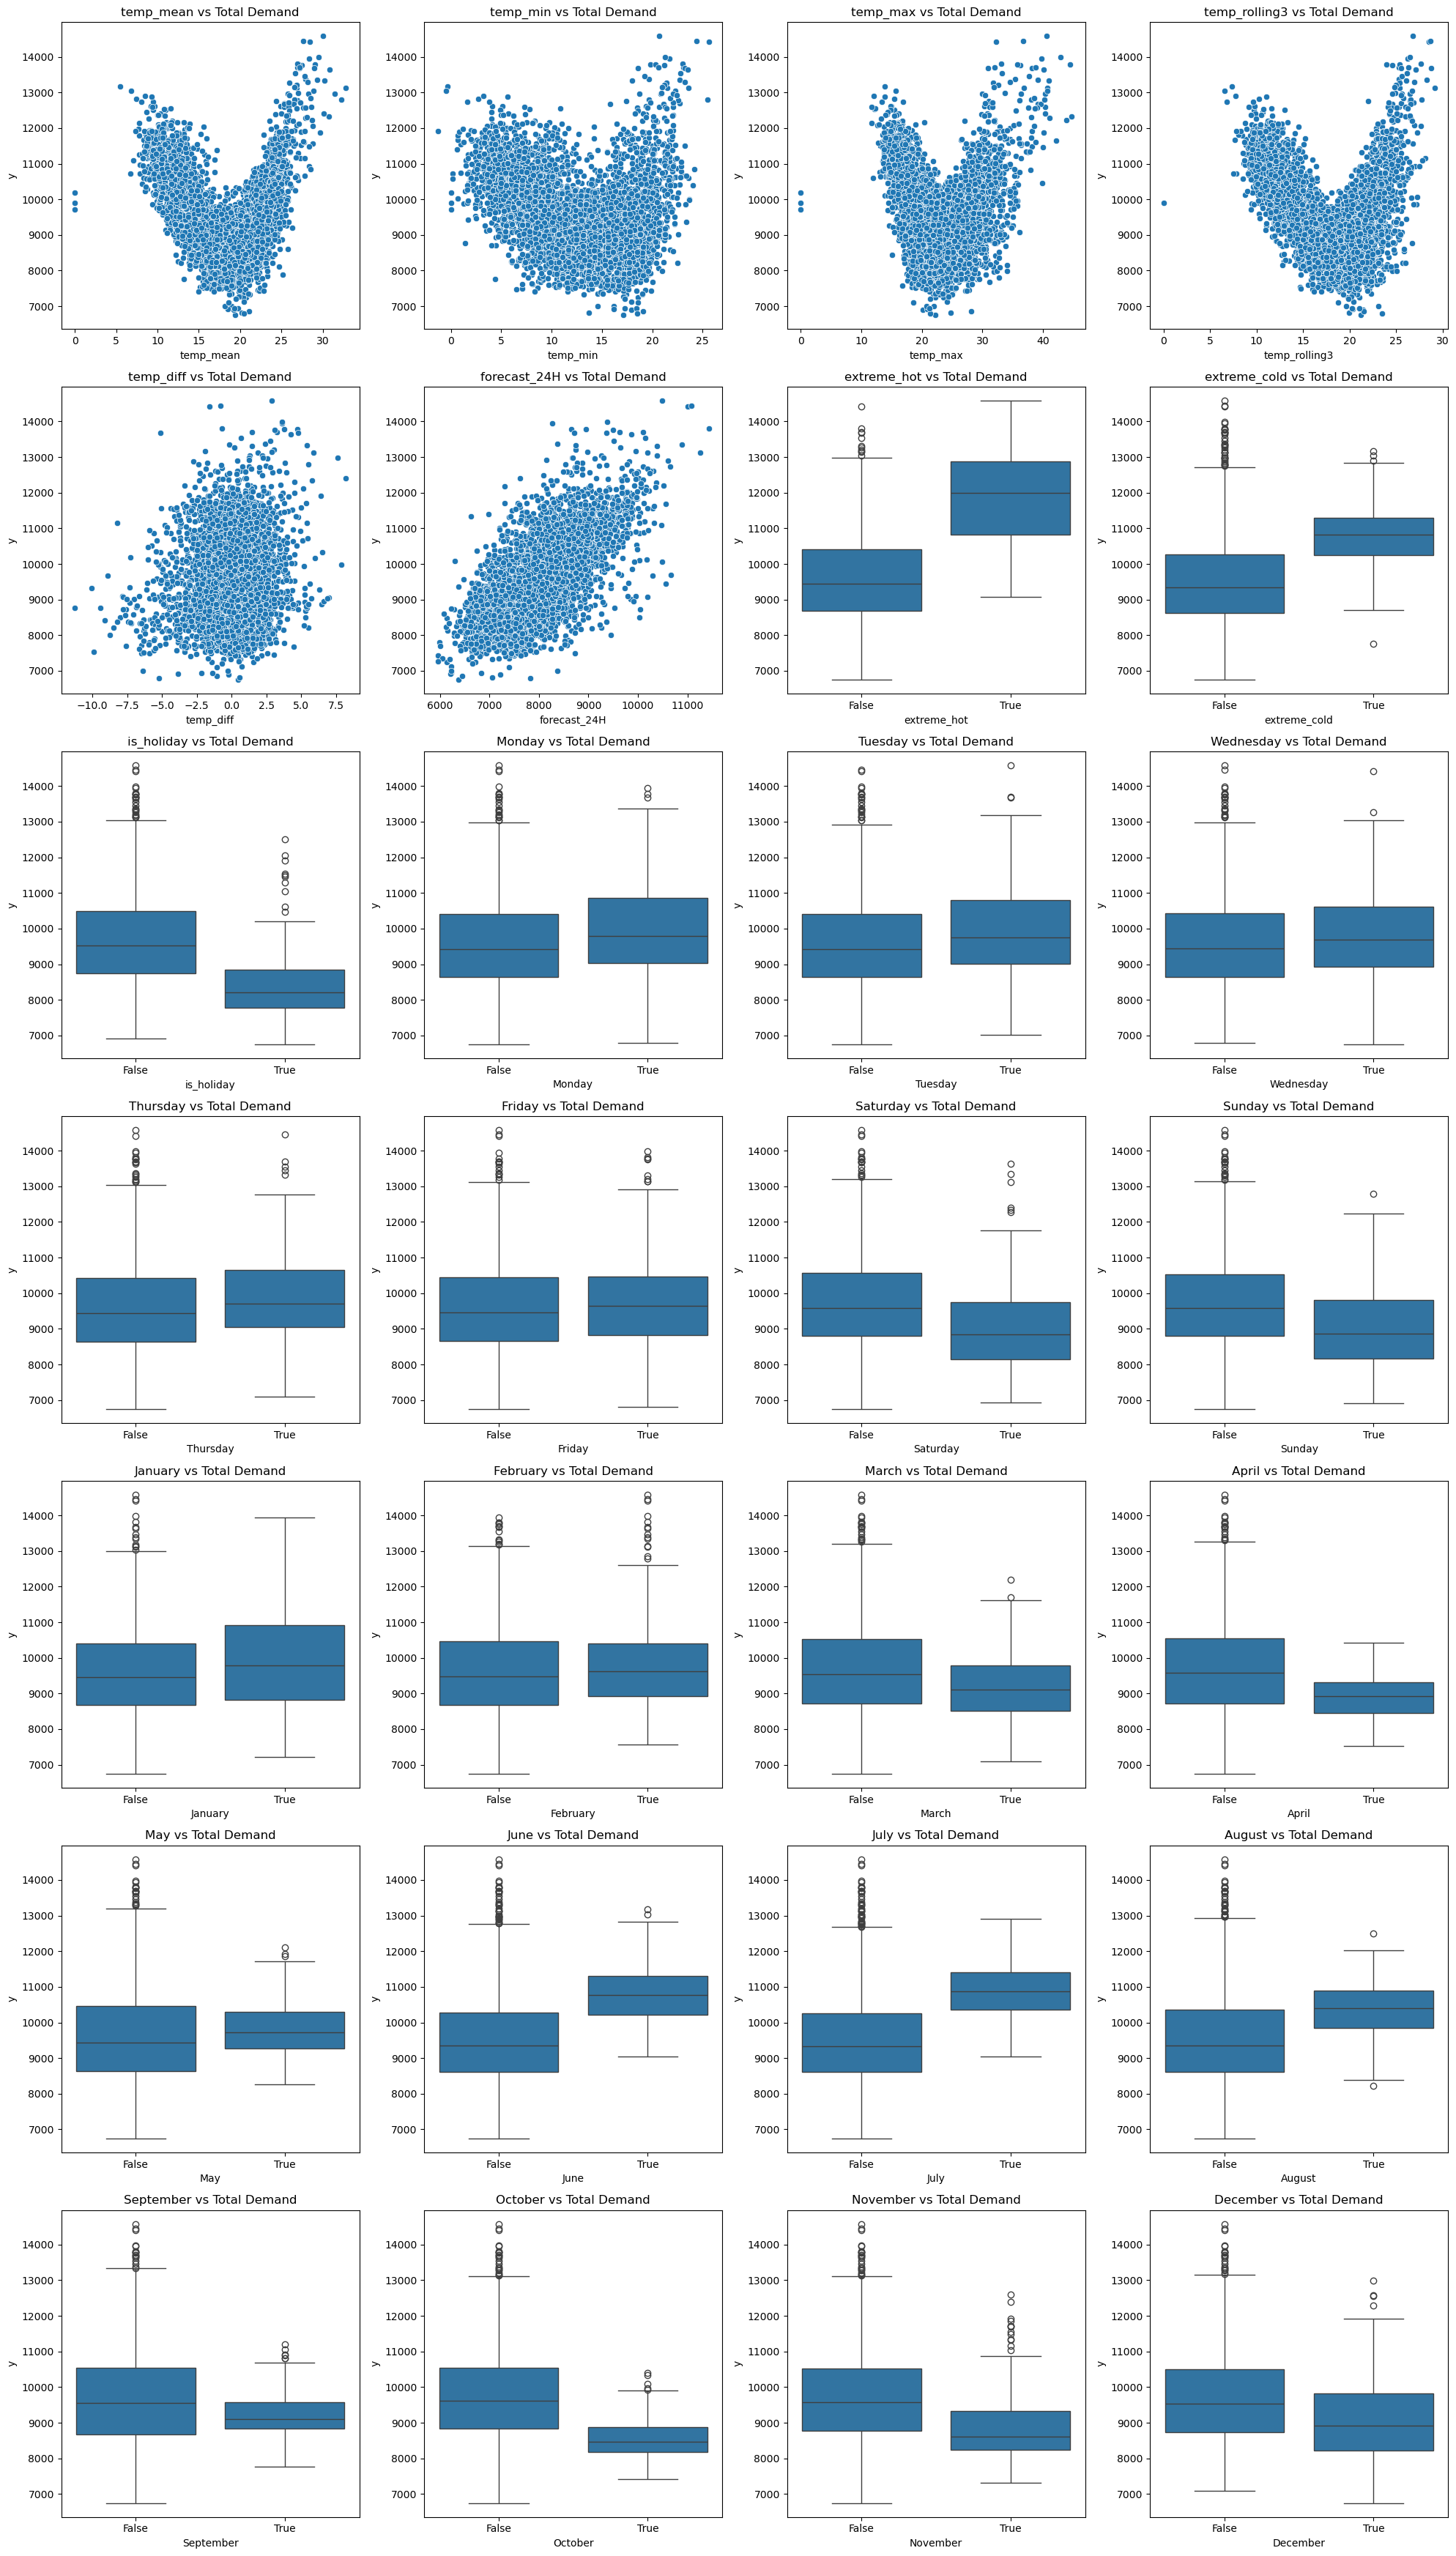

In [182]:
# Plot independent variables versus dependant variable

# Define float and boolean/categorical columns
float_cols = X.columns[:6]
bool_cols = X.columns[6:29]
all_cols = list(float_cols) + list(bool_cols)

# Total number of plots
n_plots = len(all_cols)

# Grid size
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

# Create figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

# Plot each feature against y
for i, col in enumerate(all_cols):
    ax = axes[i]
    if col in float_cols:
        sns.scatterplot(x=X[col], y=y, ax=ax)
    else:
        sns.boxplot(x=X[col], ax=ax, y=y)
    ax.set_title(f'{col} vs Total Demand')
    ax.set_xlabel(col)
    ax.set_ylabel('y')

# Hide unused subplots
for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()




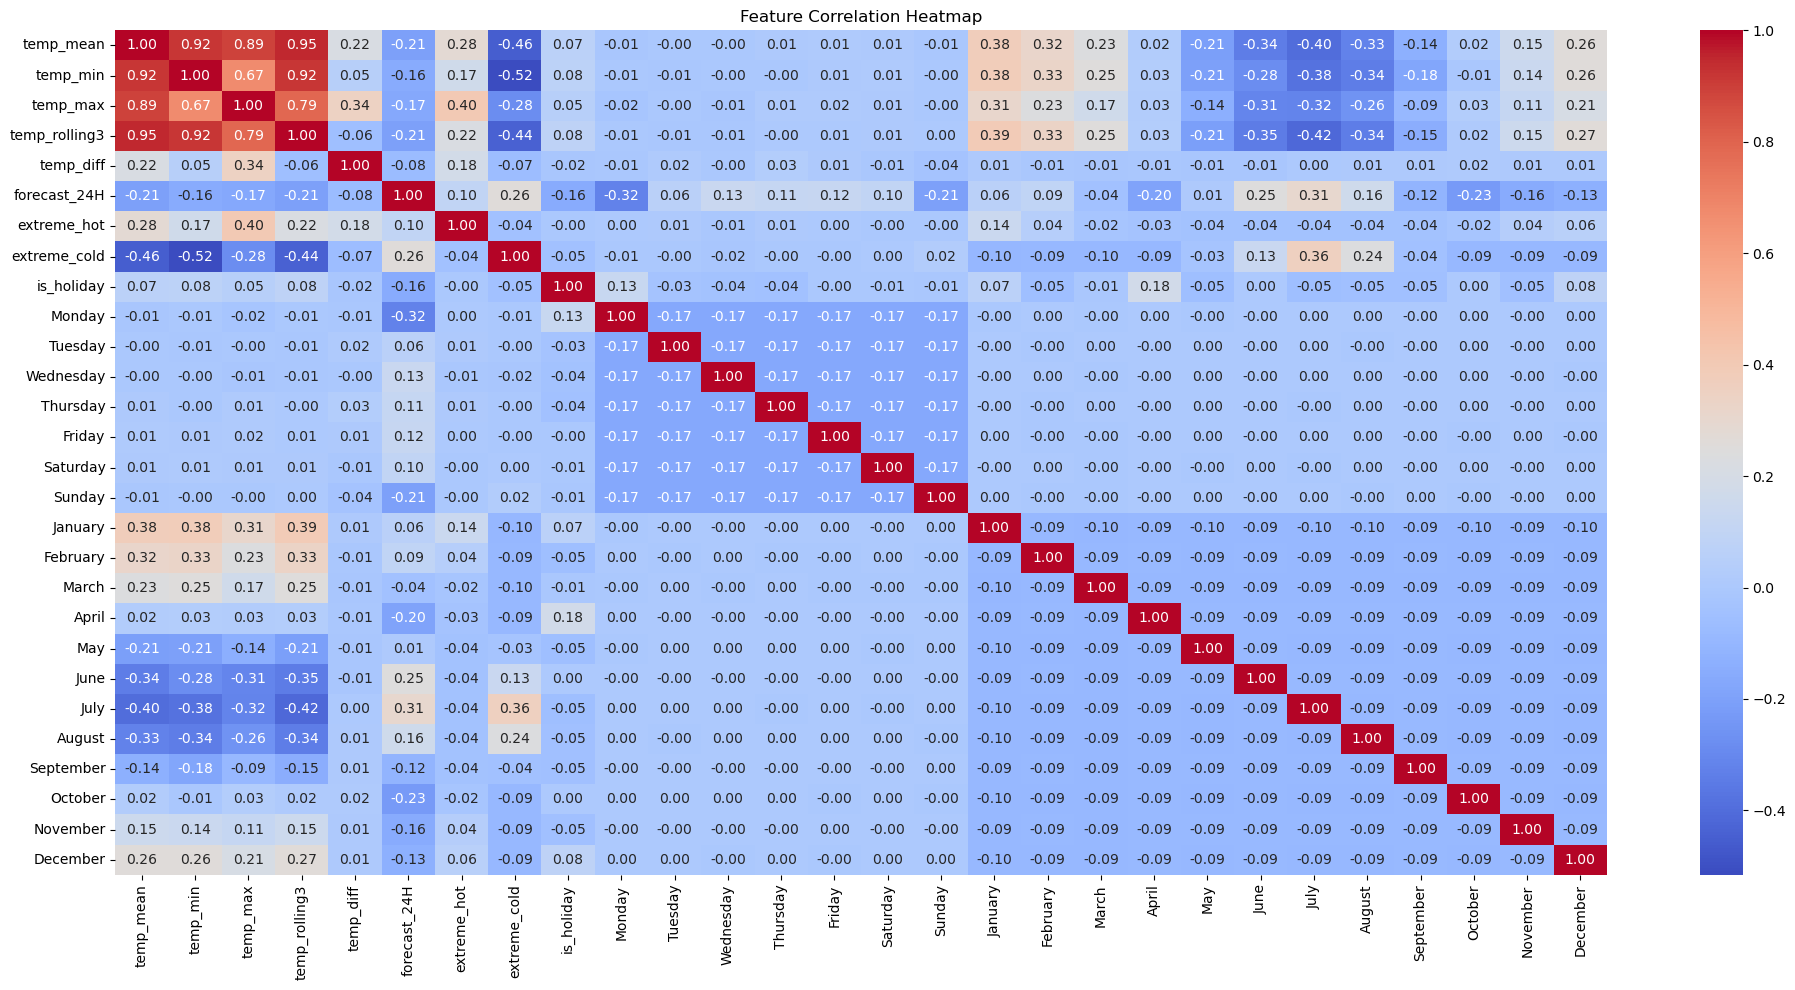

In [183]:
# Check Correlation Matrix

plt.figure(figsize=(20, 10))  
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()



Mulitple Linear Regression:

In [184]:
# Create train and test dataset (70/30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create linear regression model
model = LinearRegression()

# Fit the model
model.fit(X_train,y_train)

# Make predictions
y_pred = model.predict(X_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred))
print(
  'R_squared : ', r2_score(y_test, y_pred))

# Print Coefficient table
# Create a DataFrame of coefficients
coef_table = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

# Display
print(coef_table[['Feature', 'Coefficient']])



mean_squared_error :  315229.93542410794
mean_absolute_error :  413.80377101186866
R_squared :  0.776601429693268
          Feature  Coefficient
0       temp_mean    70.357516
1        temp_min    -7.160360
2        temp_max     8.294643
3   temp_rolling3   -32.049072
4       temp_diff    38.390510
5    forecast_24H     0.902455
6     extreme_hot  1429.334152
7    extreme_cold   235.818461
8      is_holiday  -672.089707
9          Monday   921.959437
10        Tuesday   190.338855
11      Wednesday   -24.504306
12       Thursday    28.624911
13         Friday  -113.606227
14       Saturday  -801.476401
15         Sunday  -201.336269
16        January   -29.993372
17       February  -265.080821
18          March  -463.444116
19          April  -104.583869
20            May   285.818686
21           June   782.454756
22           July   673.144193
23         August   505.534423
24      September   -49.893381
25        October  -506.718497
26       November  -465.670017
27       December 

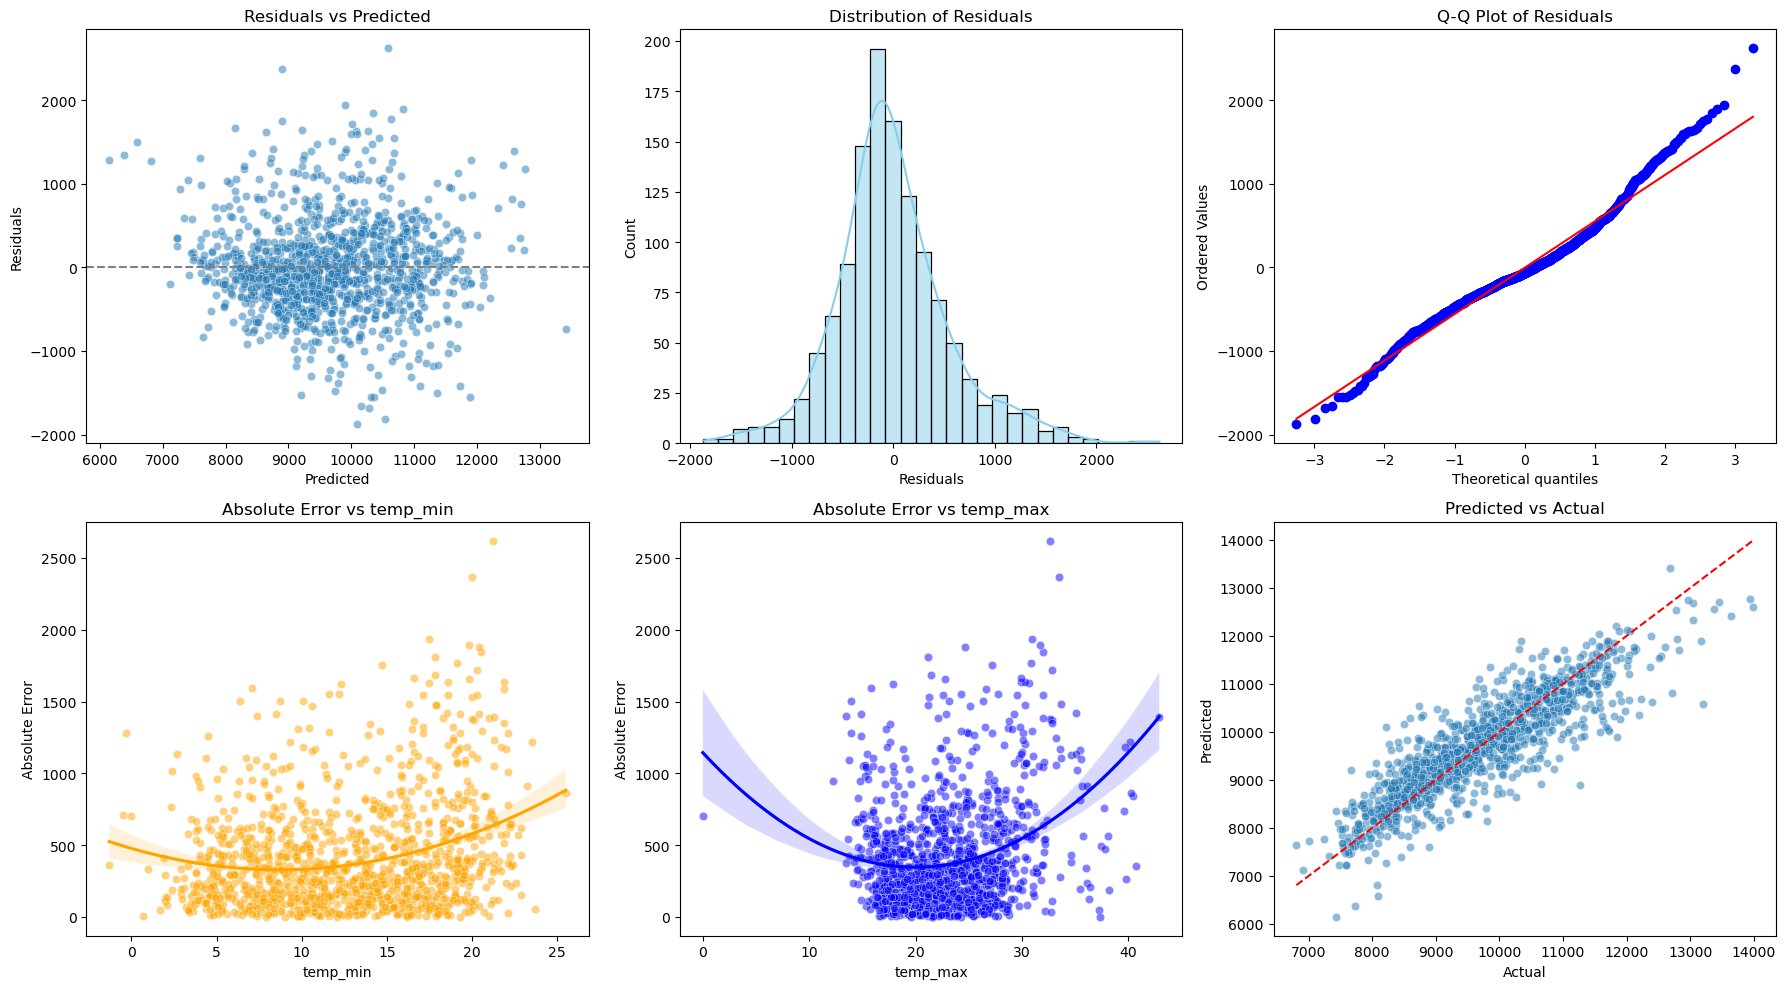

In [185]:
# Evaluation Plots

residuals = y_test - y_pred
absolute_error = np.abs(residuals)

# Create a grid of plots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Residuals vs Predicted
sns.scatterplot(x=y_pred, y=residuals, ax=axes[0, 0], alpha=0.5)
axes[0, 0].axhline(0, color='gray', linestyle='--')
axes[0, 0].set_title('Residuals vs Predicted')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Residuals')

# 2. Histogram of Residuals
sns.histplot(residuals, bins=30, kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Distribution of Residuals')
axes[0, 1].set_xlabel('Residuals')

# 3. Q-Q Plot of Residuals
stats.probplot(residuals, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot of Residuals')

# 4. Absolute Error vs temp_min
sns.scatterplot(x=X_test['temp_min'], y=absolute_error, ax=axes[1, 0], alpha=0.5, color='orange')
sns.regplot(x=X_test['temp_min'], y=absolute_error, ax=axes[1, 0], scatter=False, order=2, color='orange')
axes[1, 0].set_title('Absolute Error vs temp_min')
axes[1, 0].set_xlabel('temp_min')
axes[1, 0].set_ylabel('Absolute Error')

# 5. Absolute Error vs temp_max
sns.scatterplot(x=X_test['temp_max'], y=absolute_error, ax=axes[1, 1], alpha=0.5, color='blue')
sns.regplot(x=X_test['temp_max'], y=absolute_error, ax=axes[1, 1], scatter=False, order=2, color='blue')
axes[1, 1].set_title('Absolute Error vs temp_max')
axes[1, 1].set_xlabel('temp_max')
axes[1, 1].set_ylabel('Absolute Error')

# 6. Predicted vs Actual
sns.scatterplot(x=y_test, y=y_pred, ax=axes[1, 2], alpha=0.5)
axes[1, 2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1, 2].set_title('Predicted vs Actual')
axes[1, 2].set_xlabel('Actual')
axes[1, 2].set_ylabel('Predicted')

plt.tight_layout()
plt.show()





Multiple Linear Regression Model Using Recursive Feature Elimination:

In [186]:
# Fit RFE
rfe = RFE(model, n_features_to_select=10, step=0.5)
rfe.fit(X_train,y_train)

# Create DataFrame of rankings
rfe_df = pd.DataFrame({
    'Feature': X_train.columns,
    'RFE_Rank': rfe.ranking_
}).sort_values(by='RFE_Rank')  

# Make predictions
y_pred2 = rfe.predict(X_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred2))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred2))
print(
  'R_squared : ', r2_score(y_test, y_pred2))

# Print Coefficient table

# Get selected features and their coefficients
selected_features = X_train.columns[rfe.support_]
selected_coefs = rfe.estimator_.coef_


# Create a DataFrame of coefficients
coef_table2 = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': selected_coefs
})

# Display
print(coef_table2[['Feature', 'Coefficient']])


# Feature Importance 
rfe_table = rfe_df.sort_values(by='RFE_Rank')
print("\n Feature Importance via RFE Ranking:\n")
print(rfe_table.to_string(index=False))


mean_squared_error :  704172.8575239035
mean_absolute_error :  650.5056371478278
R_squared :  0.5009636080152068
       Feature  Coefficient
0  extreme_hot  2904.935272
1   is_holiday  -928.021823
2     Saturday  -706.118105
3          May   428.124775
4         June  1430.326548
5         July  1504.209322
6       August   996.353836
7      October  -832.097231
8     November  -609.321425
9     December  -352.313269

 Feature Importance via RFE Ranking:

      Feature  RFE_Rank
     December         1
      October         1
       August         1
         July         1
         June         1
  extreme_hot         1
   is_holiday         1
          May         1
     November         1
     Saturday         1
        March         2
     February         2
 extreme_cold         2
       Monday         2
      January         3
    September         3
        April         3
    temp_mean         3
       Sunday         3
     Thursday         3
    Wednesday         3
      Tuesda

Polynomial Regression Model:

In [187]:
# 2nd Degree Polynomial

# Create Polynomial Features
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly2_train = poly2.fit_transform(X_train)
X_poly2_test = poly2.fit_transform(X_test)
feature_names = poly2.get_feature_names_out(X_train.columns)

# Fit the model
poly2_model = model.fit(X_poly2_train, y_train)

# Make predictions
y_pred3 = poly2_model.predict(X_poly2_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred3))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred3))
print(
  'R_squared : ', r2_score(y_test, y_pred3))

# Print Coefficient table
# Create a DataFrame of coefficients
coef_table3 = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': poly2_model.coef_
})

# Display
print(coef_table3[['Feature', 'Coefficient']])

mean_squared_error :  134661.8669816521
mean_absolute_error :  266.2221281886362
R_squared :  0.9045672216439007
               Feature  Coefficient
0            temp_mean  -686.530868
1             temp_min   -23.844742
2             temp_max   -46.543465
3        temp_rolling3   731.736861
4            temp_diff   -68.767000
..                 ...          ...
429   October November     0.000000
430   October December     0.000000
431         November^2 -1156.570154
432  November December     0.000000
433         December^2 -1771.704399

[434 rows x 2 columns]


In [188]:
# 3rd Degree Polynomial

# Create Polynomial Features
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly3_train = poly3.fit_transform(X_train)
X_poly3_test = poly3.fit_transform(X_test)
feature_names3 = poly3.get_feature_names_out(X_train.columns)

# Fit the model
poly3_model = model.fit(X_poly3_train, y_train)

# Make predictions
y_pred4 = poly3_model.predict(X_poly3_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred4))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred4))
print(
  'R_squared : ', r2_score(y_test, y_pred4))

# Print Coefficient table
# Create a DataFrame of coefficients
coef_table4 = pd.DataFrame({
    'Feature': feature_names3,
    'Coefficient': poly3_model.coef_
})

# Display
print(coef_table4[['Feature', 'Coefficient']])

mean_squared_error :  487349.51448151947
mean_absolute_error :  366.808089178569
R_squared :  0.6546229512486677
                  Feature  Coefficient
0               temp_mean -6607.902713
1                temp_min  -407.299957
2                temp_max   403.586987
3           temp_rolling3  5179.286551
4               temp_diff  1876.064471
...                   ...          ...
4489   October December^2     0.000000
4490           November^3 -3440.942922
4491  November^2 December     0.000000
4492  November December^2     0.000000
4493           December^3 -4812.121608

[4494 rows x 2 columns]


2nd Degree Polynomial Lasso Regression

In [189]:
# Lasso Regression Model
model2 = make_pipeline(StandardScaler(), Lasso(alpha=0.9, max_iter=100000))

# Fit the model
poly2_lasso = model2.fit(X_poly2_train, y_train)

# Make predictions
y_pred5 = poly2_lasso.predict(X_poly2_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred5))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred5))
print(
  'R_squared : ', r2_score(y_test, y_pred5))

# Print Coefficient table
# Create a DataFrame of coefficients
lasso = model2.named_steps['lasso']

coef_table5 = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso.coef_,
    'Abs_Coef' : np.abs(lasso.coef_)
}).sort_values(by='Abs_Coef', ascending=False)


# Display
print(coef_table5[['Feature', 'Coefficient']])




mean_squared_error :  133502.79137529095
mean_absolute_error :  269.0397729377178
R_squared :  0.9053886405646326
                    Feature  Coefficient
84   temp_max temp_rolling3  1063.988926
356               January^2  -688.664167
2                  temp_max  -650.900910
368              February^2  -618.549502
28              temp_mean^2   616.566665
..                      ...          ...
265        Tuesday Thursday     0.000000
266          Tuesday Friday     0.000000
267        Tuesday Saturday     0.000000
268          Tuesday Sunday     0.000000
38        temp_mean Tuesday    -0.000000

[434 rows x 2 columns]


Model Evaluation:

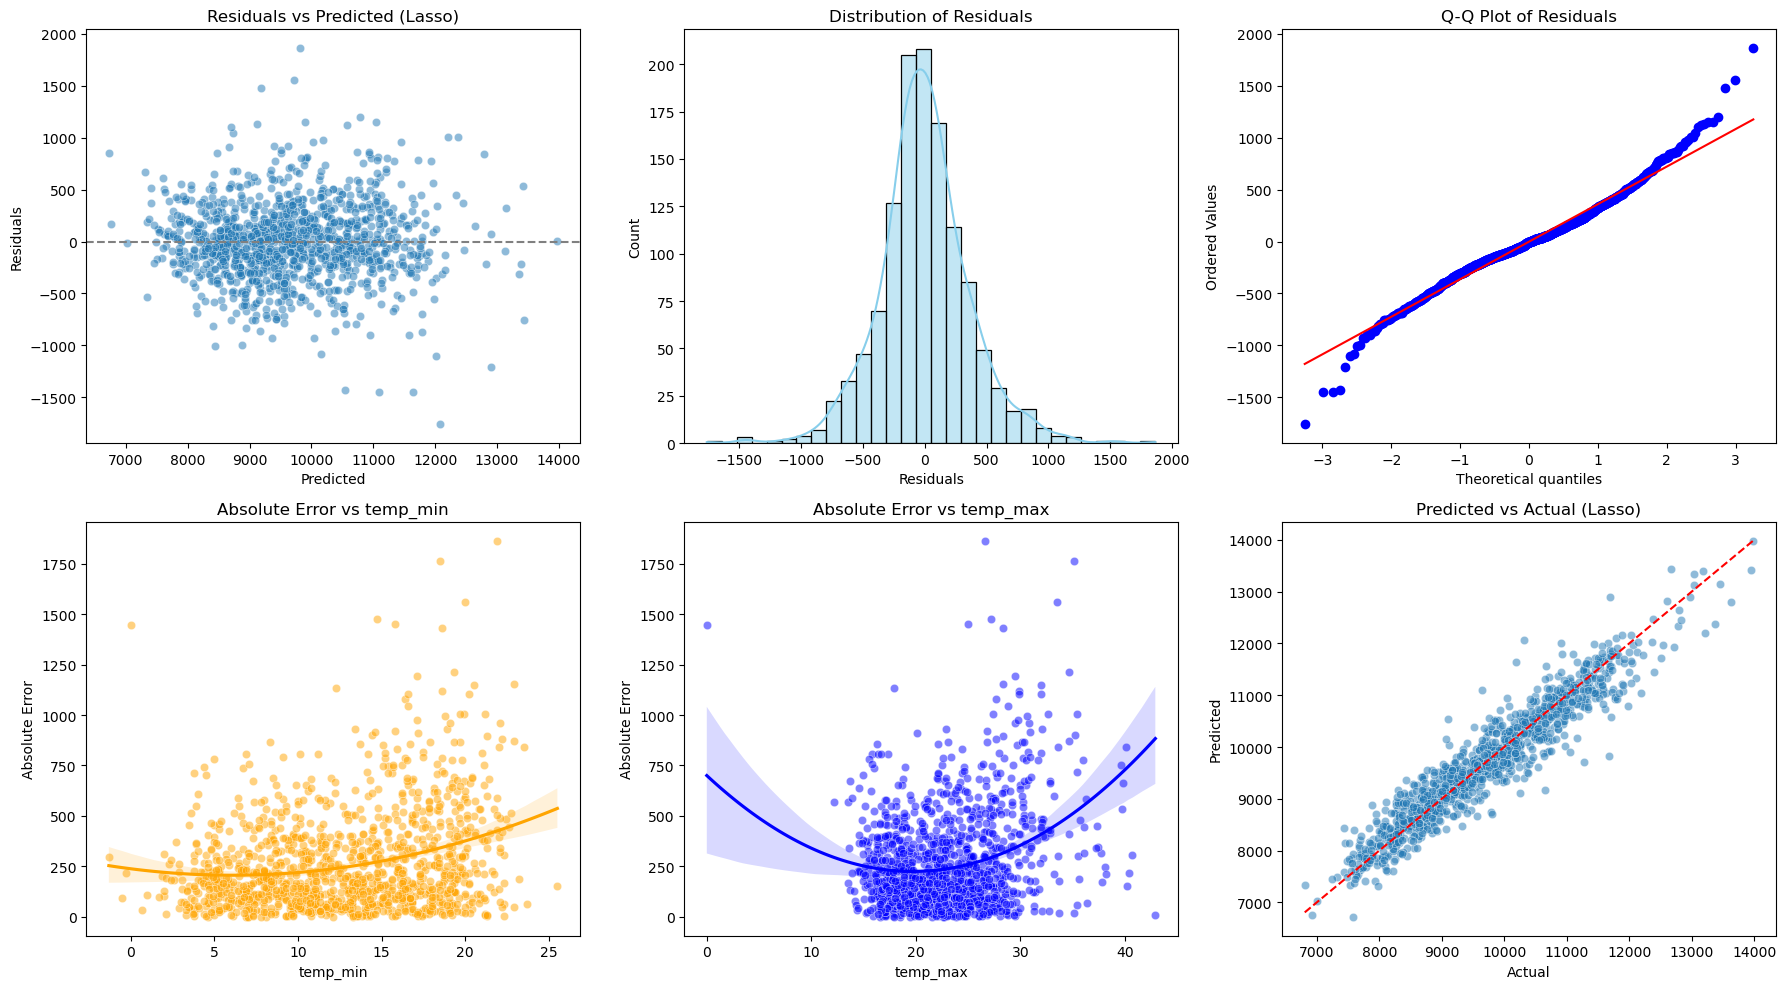

In [190]:
# Evaluation Plots

# Residuals and absolute error for Lasso predictions
residuals_2 = y_test - y_pred5
absolute_error = np.abs(residuals_2)

# Create a grid of plots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Residuals vs Predicted
sns.scatterplot(x=y_pred5, y=residuals_2, ax=axes[0, 0], alpha=0.5)
axes[0, 0].axhline(0, color='gray', linestyle='--')
axes[0, 0].set_title('Residuals vs Predicted (Lasso)')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Residuals')

# 2. Histogram of Residuals
sns.histplot(residuals_2, bins=30, kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Distribution of Residuals')
axes[0, 1].set_xlabel('Residuals')

# 3. Q-Q Plot of Residuals
stats.probplot(residuals_2, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot of Residuals')

# 4. Absolute Error vs temp_min
sns.scatterplot(x=X_test['temp_min'], y=absolute_error, ax=axes[1, 0], alpha=0.5, color='orange')
sns.regplot(x=X_test['temp_min'], y=absolute_error, ax=axes[1, 0], scatter=False, order=2, color='orange')
axes[1, 0].set_title('Absolute Error vs temp_min')
axes[1, 0].set_xlabel('temp_min')
axes[1, 0].set_ylabel('Absolute Error')

# 5. Absolute Error vs temp_max
sns.scatterplot(x=X_test['temp_max'], y=absolute_error, ax=axes[1, 1], alpha=0.5, color='blue')
sns.regplot(x=X_test['temp_max'], y=absolute_error, ax=axes[1, 1], scatter=False, order=2, color='blue')
axes[1, 1].set_title('Absolute Error vs temp_max')
axes[1, 1].set_xlabel('temp_max')
axes[1, 1].set_ylabel('Absolute Error')

# 6. Predicted vs Actual
sns.scatterplot(x=y_test, y=y_pred5, ax=axes[1, 2], alpha=0.5)
axes[1, 2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1, 2].set_title('Predicted vs Actual (Lasso)')
axes[1, 2].set_xlabel('Actual')
axes[1, 2].set_ylabel('Predicted')

plt.tight_layout()
plt.show()


Run model over full data set:

In [191]:
# Assign full dataset
X_poly2 = poly2.fit_transform(X)


# Make predictions
y_pred_full = poly2_lasso.predict(X_poly2)



In [192]:
# Calculate Improvement from Base Model Performance

# Base model predictions (from df_daily)

# Align forecast demand 
forecast_base = df_daily['FORECASTDEMAND']['max']
y_base = df_daily['TOTALDEMAND']['max'] 


# Metrics for base forecast
mae_base = mean_absolute_error(y_base, forecast_base)
rmse_base = math.sqrt(mean_squared_error(y_base, forecast_base))
r2_base = r2_score(y_base, forecast_base)

# Metrics for MLR model
mae_mlr = mean_absolute_error(y, y_pred_full)
rmse_mlr = math.sqrt(mean_squared_error(y, y_pred_full))
r2_mlr = r2_score(y, y_pred_full)

# Print comparison
print(" Performance Comparison")
print(f"Base Forecast → MAE: {mae_base:.2f}, RMSE: {rmse_base:.2f}, R²: {r2_base:.4f}")
print(f"MLR Model     → MAE: {mae_mlr:.2f}, RMSE: {rmse_mlr:.2f}, R²: {r2_mlr:.4f}")


#calculate improvement
mae_improvement = mae_base - mae_mlr
rmse_improvement = rmse_base - rmse_mlr
r2_improvement = r2_mlr - r2_base
print(f"\nMAE improvement: {mae_improvement:.1f} MW ({mae_improvement/mae_base*100:.1f}%)")
print(f"RMSE improvement: {rmse_improvement:.1f} MW ({rmse_improvement/rmse_base*100:.1f}%)")
print(f"R² improvement: {r2_improvement:.3f} ({r2_improvement/r2_base*100:.1f}%)")

 Performance Comparison
Base Forecast → MAE: 181.43, RMSE: 243.93, R²: 0.9586
MLR Model     → MAE: 257.14, RMSE: 351.91, R²: 0.9138

MAE improvement: -75.7 MW (-41.7%)
RMSE improvement: -108.0 MW (-44.3%)
R² improvement: -0.045 (-4.7%)



Improvement by temperature extremes (MLR):


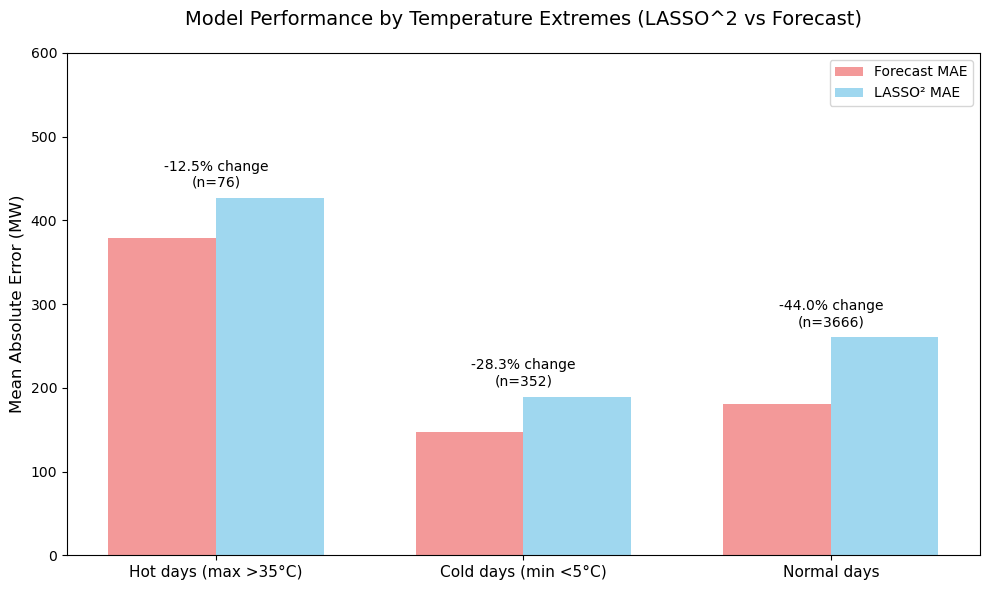

Hot days (max >35°C): {'n': 76, 'forecast_MAE': 378.8886753813408, 'forecast_RMSE': 455.36751510109497, 'forecast_R2': 0.8744388645473511, 'MLR_MAE': 426.3573572479529, 'MLR_RMSE': 558.2006740609074, 'MLR_R2': 0.8113260872610989, 'MAE_reduction': -47.46868186661209, 'RMSE_reduction': -102.83315895981247, 'R2_improvement': -0.0631127772862522}
Cold days (min <5°C): {'n': 352, 'forecast_MAE': 147.59488477120746, 'forecast_RMSE': 191.1441713586701, 'forecast_R2': 0.94550713076197, 'MLR_MAE': 189.40739378240016, 'MLR_RMSE': 246.70011815706275, 'MLR_R2': 0.9092270871878148, 'MAE_reduction': -41.8125090111927, 'RMSE_reduction': -55.555946798392654, 'R2_improvement': -0.03628004357415526}
Normal days: {'n': 3666, 'forecast_MAE': 180.59076373173863, 'forecast_RMSE': 242.1592749082972, 'forecast_R2': 0.9528337017489041, 'MLR_MAE': 260.13063900807776, 'MLR_RMSE': 354.9623745025086, 'MLR_R2': 0.8986568918945526, 'MAE_reduction': -79.53987527633913, 'RMSE_reduction': -112.80309959421143, 'R2_impro

In [204]:
# Metrics Evaluation for Extreme Weather Events

# Define Metrics
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    
    # R-squared
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    metrics = {"MAE":mae, "RMSE":rmse, "R2":r2}
    return metrics


#Create DataFrames for Residuals and Predictions

# MLR
results_df = X.copy()
results_df['ACTUAL'] = y
results_df['PRED_MLR'] = y_pred_full

# Base Model
forecast_test = df_daily['FORECASTDEMAND']['max']
results_df['FORECAST'] = forecast_test.values 

# Residuals
results_df['RESID_FORECAST'] = results_df['ACTUAL'] - results_df['FORECAST']
results_df['RESID_MLR'] = results_df['ACTUAL'] - results_df['PRED_MLR']

# Add Temperature Categories
results_df['is_extreme_hot'] = df_daily['extreme_hot'].astype(int).values
results_df['is_extreme_cold'] = df_daily['extreme_cold'].astype(int).values


def improvement_by_temp_extremes(dframe):
    hot = dframe.loc[dframe["is_extreme_hot"] == 1] # Max temp > 35°C
    cold = dframe.loc[dframe["is_extreme_cold"] == 1] # Min temp < 5°C
    normal = dframe.loc[(dframe["is_extreme_hot"] == 0) & (dframe["is_extreme_cold"] == 0)]
    
    def comp(sub, label):
        if len(sub) == 0:
            return {}
        fc = metrics(sub["ACTUAL"].values, sub["FORECAST"].values)
        mlr = metrics(sub["ACTUAL"].values, sub["PRED_MLR"].values)
        return {
        label: {
            "n": len(sub),
            "forecast_MAE": fc["MAE"],
            "forecast_RMSE": fc["RMSE"],
            "forecast_R2": fc["R2"],
            "MLR_MAE": mlr["MAE"],
            "MLR_RMSE": mlr["RMSE"],
            "MLR_R2": mlr["R2"],
            "MAE_reduction": fc["MAE"] - mlr["MAE"],
            "RMSE_reduction": fc["RMSE"] - mlr["RMSE"],
            "R2_improvement": mlr["R2"] - fc["R2"]
        }
    }



    print("\nImprovement by temperature extremes (MLR):")
    result = {}
    result.update(comp(hot, "Hot days (max >35°C)"))
    result.update(comp(cold, "Cold days (min <5°C)"))
    result.update(comp(normal, "Normal days"))

    # Plot Temperature Extremes
    # Extract values from result dictionary
    categories = list(result.keys())
    forecast_mae = [result[cat]['forecast_MAE'] for cat in categories]
    mlr_mae = [result[cat]['MLR_MAE'] for cat in categories]
    n_values = [result[cat]['n'] for cat in categories]
    mae_diff = [result[cat]['MAE_reduction'] for cat in categories]

    # Bar positions
    x = np.arange(len(categories))
    width = 0.35

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, forecast_mae, width, label='Forecast MAE', color='lightcoral', alpha = 0.8)
    bars2 = ax.bar(x + width/2, mlr_mae, width, label='LASSO² MAE', color='skyblue', alpha = 0.8)

    # Annotate bars with % change and sample size
    for i in range(len(categories)):
        pct_change = (mae_diff[i] / forecast_mae[i]) * 100
        ax.text(x[i], max(forecast_mae[i], mlr_mae[i]) + 10,
            f"{pct_change:.1f}% change\n(n={n_values[i]})",
            ha='center', va='bottom', fontsize=10)

    # Labels and styling
    ax.set_ylim(0, 600)
    ax.set_ylabel('Mean Absolute Error (MW)', fontsize=12)
    ax.set_title('Model Performance by Temperature Extremes (LASSO^2 vs Forecast)', fontsize=14, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=11)
    ax.legend()

    
    plt.tight_layout()
    plt.show()


    for key, values in result.items():
        clean_values = {k: float(v) if isinstance(v, np.generic) else v for k, v in values.items()}
        print(f"{key}: {clean_values}")

    # Compare to original model (forecast) accuracy
    print("\nOriginal Model (Forecast) Accuracy:")
    mae_forecast = mean_absolute_error(dframe['ACTUAL'], dframe['FORECAST'])
    rmse_forecast = math.sqrt(mean_squared_error(dframe['ACTUAL'], dframe['FORECAST']))
    r2_forecast = r2_score(dframe['ACTUAL'], dframe['FORECAST'])
    print(f"Forecast MAE: {mae_forecast:.2f}")
    print(f"Forecast RMSE: {rmse_forecast:.2f}")
    print(f"Forecast R2: {r2_forecast:.4f}")

    print("\nMLR Model Accuracy:")
    mae_mlr = mean_absolute_error(dframe['ACTUAL'], dframe['PRED_MLR'])
    rmse_mlr = math.sqrt(mean_squared_error(dframe['ACTUAL'], dframe['PRED_MLR']))
    r2_mlr = r2_score(dframe['ACTUAL'], dframe['PRED_MLR'])
    print(f"MLR MAE: {mae_mlr:.2f}")
    print(f"MLR RMSE: {rmse_mlr:.2f}")
    print(f"MLR R2: {r2_mlr:.4f}")
    return result


result = improvement_by_temp_extremes(results_df)


# Create summary table of % improvements
print("\n Percentage Improvement by Temperature Category:")
summary = []
for label, values in result.items():
        mae_pct = (values["MAE_reduction"] / values["forecast_MAE"] * 100) if values["forecast_MAE"] != 0 else 0
        rmse_pct = (values["RMSE_reduction"] / values["forecast_RMSE"] * 100) if values["forecast_RMSE"] != 0 else 0
        r2_pct = (values["R2_improvement"] / abs(values["forecast_R2"]) * 100) if values["forecast_R2"] != 0 else 0
        summary.append({
            "Category": label,
            "MAE % Improvement": f"{mae_pct:.1f}%",
            "RMSE % Improvement": f"{rmse_pct:.1f}%",
            "R² % Improvement": f"{r2_pct:.1f}%"
        })
        
# Display as table
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))


 Generate Comparison Plots using Temperature Bins:

C:\Users\lizmu\AppData\Local\Temp\ipykernel_29640\3542515918.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_forecast_max = error_forecast.groupby(bins_max).median()
C:\Users\lizmu\AppData\Local\Temp\ipykernel_29640\3542515918.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_mlr_max = error_mlr_max.groupby(bins_max).median()


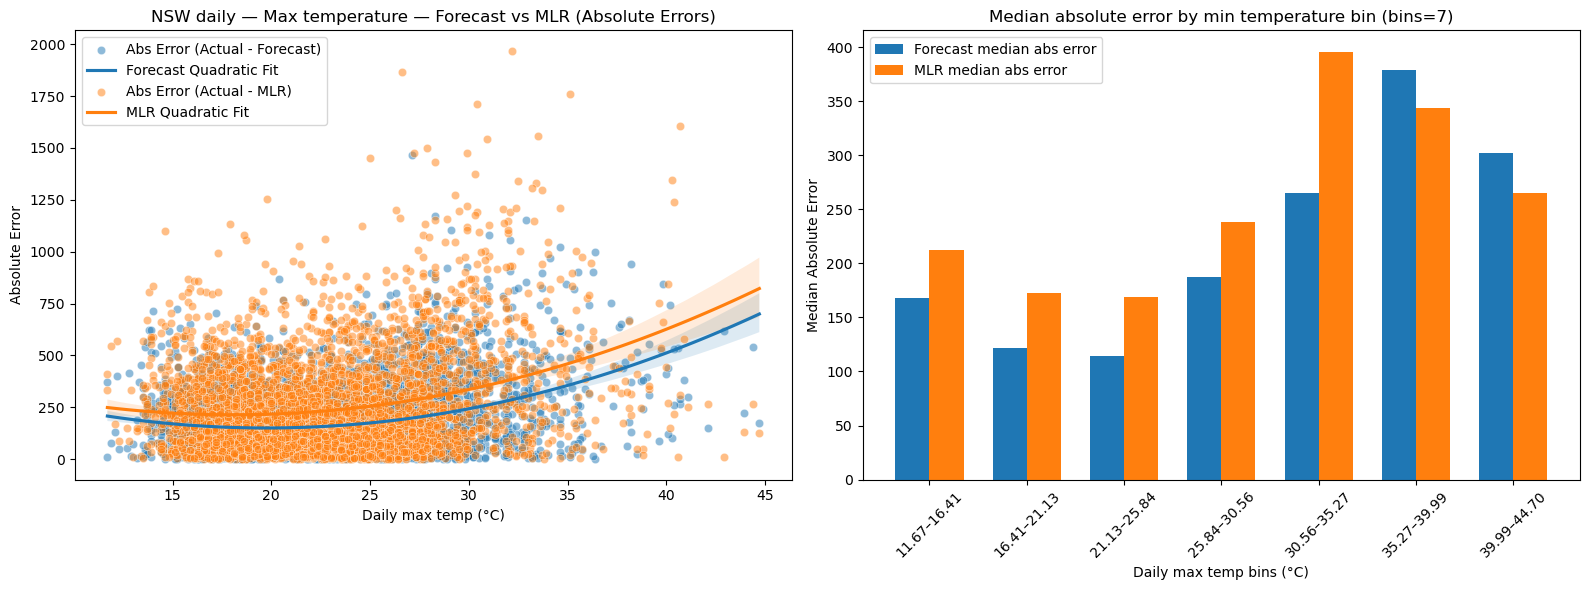

C:\Users\lizmu\AppData\Local\Temp\ipykernel_29640\3542515918.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_forecast_min = error_forecast.groupby(bins_min).median()
C:\Users\lizmu\AppData\Local\Temp\ipykernel_29640\3542515918.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_mlr_min = error_mlr_min.groupby(bins_min).median()


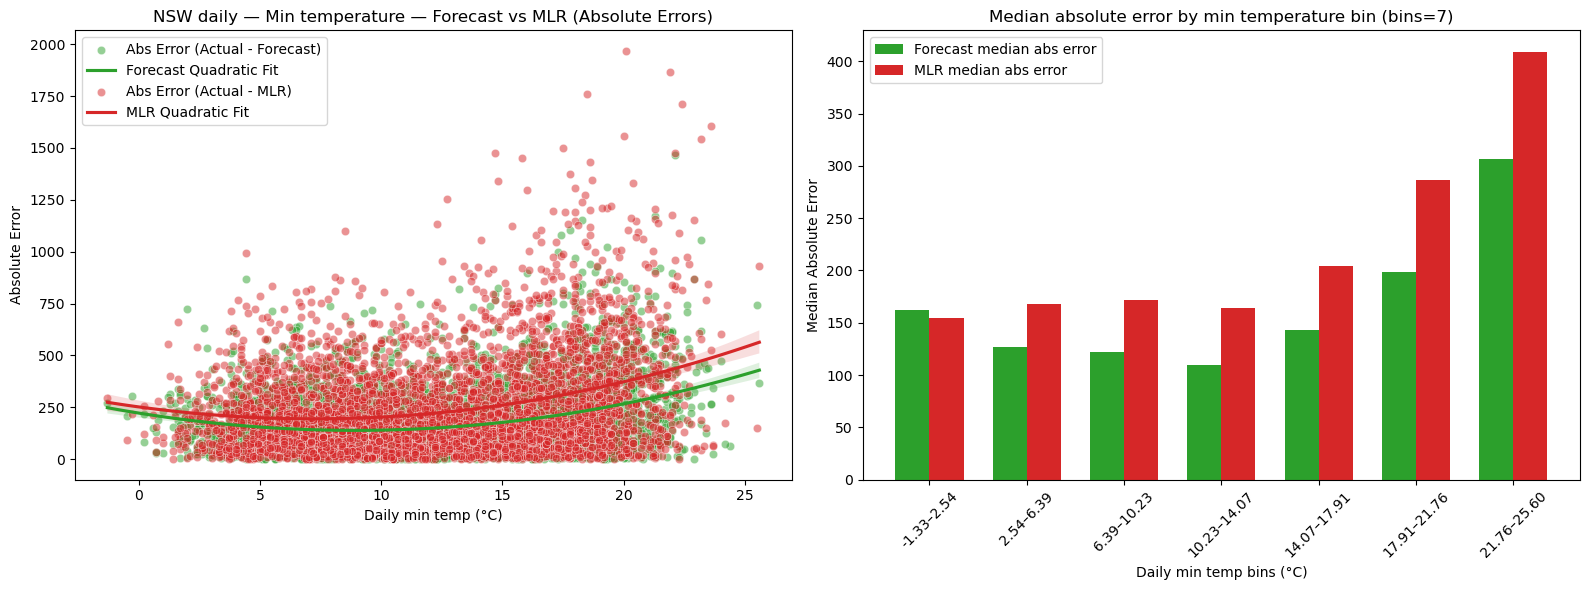

In [194]:
# Absolute errors
from matplotlib.pyplot import xlabel


error_forecast = abs(df_daily['TOTALDEMAND']['max'] - df_daily['FORECASTDEMAND']['max'])
error_mlr = abs(y - y_pred_full)
temp_max = df_daily['TEMPERATURE']['max']
temp_min = df_daily['TEMPERATURE']['min']
error_mlr_max = pd.Series(error_mlr, index=temp_max.index)
error_mlr_min = pd.Series(error_mlr, index=temp_min.index)


# Define temperature bins
bins_max = pd.cut(temp_max, bins=7)
bins_min = pd.cut(temp_min, bins=7)

# Plot formatting
width = 0.35

# Max Temperature

# Group errors by bins
grouped_forecast_max = error_forecast.groupby(bins_max).median()
grouped_mlr_max = error_mlr_max.groupby(bins_max).median()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x_labels_max = [f"{interval.left:.2f}–{interval.right:.2f}" for interval in grouped_forecast_max.index]
x_max = np.arange(len(x_labels_max))

# Scatter plot (left)
sns.scatterplot(ax=axes[0], x=temp_max, y=error_forecast, label='Abs Error (Actual - Forecast)', color='C0', alpha=0.5)
sns.regplot(ax=axes[0], x=temp_max, y=error_forecast, scatter=False, order=2, label='Forecast Quadratic Fit', color='C0')
sns.scatterplot(ax=axes[0], x=temp_max, y=error_mlr, label='Abs Error (Actual - MLR)', color='C1', alpha=0.5)
sns.regplot(ax=axes[0], x=temp_max, y=error_mlr, scatter=False, order=2, label='MLR Quadratic Fit', color='C1')
axes[0].set_title("NSW daily — Max temperature — Forecast vs MLR (Absolute Errors)")
axes[0].set_xlabel("Daily max temp (°C)")
axes[0].set_ylabel("Absolute Error")
axes[0].legend()

# Bar chart (right)
axes[1].bar(x_max - width/2, grouped_forecast_max.values, width, label='Forecast median abs error', color='C0')
axes[1].bar(x_max + width/2, grouped_mlr_max.values, width, label='MLR median abs error', color='C1')
axes[1].set_xticks(x_max)
axes[1].set_xticklabels(x_labels_max, rotation=45)
axes[1].set_xlabel("Daily max temp bins (°C)")
axes[1].set_ylabel("Median Absolute Error")
axes[1].set_title("Median absolute error by min temperature bin (bins=7)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Min Temperature

# Group errors by bins
grouped_forecast_min = error_forecast.groupby(bins_min).median()
grouped_mlr_min = error_mlr_min.groupby(bins_min).median()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x_labels_min = [f"{interval.left:.2f}–{interval.right:.2f}" for interval in grouped_forecast_min.index]
x_min = np.arange(len(x_labels_min))

# Scatter plot (left)
sns.scatterplot(ax=axes[0], x=temp_min, y=error_forecast, label='Abs Error (Actual - Forecast)', color='C2', alpha=0.5)
sns.regplot(ax=axes[0], x=temp_min, y=error_forecast, scatter=False, order=2, label='Forecast Quadratic Fit', color='C2')
sns.scatterplot(ax=axes[0], x=temp_min, y=error_mlr, label='Abs Error (Actual - MLR)', color='C3', alpha=0.5)
sns.regplot(ax=axes[0], x=temp_min, y=error_mlr, scatter=False, order=2, label='MLR Quadratic Fit', color='C3')
axes[0].set_title("NSW daily — Min temperature — Forecast vs MLR (Absolute Errors)")
axes[0].set_xlabel("Daily min temp (°C)")
axes[0].set_ylabel("Absolute Error")
axes[0].legend()

# Bar chart (right)
axes[1].bar(x_min - width/2, grouped_forecast_min.values, width, label='Forecast median abs error', color='C2')
axes[1].bar(x_min + width/2, grouped_mlr_min.values, width, label='MLR median abs error', color='C3')
axes[1].set_xticks(x_max)
axes[1].set_xticklabels(x_labels_min, rotation=45)
axes[1].set_xlabel("Daily min temp bins (°C)")
axes[1].set_ylabel("Median Absolute Error")
axes[1].set_title("Median absolute error by min temperature bin (bins=7)")
axes[1].legend()

plt.tight_layout()
plt.show()